# Bias Audit Report: Adult Census Income Dataset

## Objective
The objective of this notebook is to conduct a comprehensive bias audit of a machine learning model trained on the Adult Census Income dataset. The audit identifies demographic bias, evaluates it using quantitative fairness metrics, applies bias mitigation strategies, and discusses ethical implications related to real-world deployment.


## Dataset Selection and Bias Risk

The Adult Census Income dataset contains demographic and employment-related information used to predict whether an individual earns more than $50,000 per year. Features include age, education, occupation, race, and sex.

This dataset is known to reflect historical income inequality, particularly along gender and racial lines. As a result, models trained on this data may reproduce or amplify existing societal biases if fairness is not explicitly examined.


In [1]:
import pandas as pd
import numpy as np

# Load Adult dataset (stored as one column)
df = pd.read_csv("adult.csv", header=None)

# Split the single column into 15 columns
df = df[0].str.split(",", expand=True)

# Assign correct column names
df.columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

# Remove extra spaces
df = df.apply(lambda col: col.str.strip())

# Handle missing values
df = df.replace("?", np.nan).dropna()

df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,age,"""workclass""","""fnlwgt""","""education""","""education.num""","""marital.status""","""occupation""","""relationship""","""race""","""sex""","""capital.gain""","""capital.loss""","""hours.per.week""","""native.country""","""income"""
1,90,"""?""",77053,"""HS-grad""",9,"""Widowed""","""?""","""Not-in-family""","""White""","""Female""",0,4356,40,"""United-States""","""<=50K"""
2,82,"""Private""",132870,"""HS-grad""",9,"""Widowed""","""Exec-managerial""","""Not-in-family""","""White""","""Female""",0,4356,18,"""United-States""","""<=50K"""
3,66,"""?""",186061,"""Some-college""",10,"""Widowed""","""?""","""Unmarried""","""Black""","""Female""",0,4356,40,"""United-States""","""<=50K"""
4,54,"""Private""",140359,"""7th-8th""",4,"""Divorced""","""Machine-op-inspct""","""Unmarried""","""White""","""Female""",0,3900,40,"""United-States""","""<=50K"""


In [2]:
df["income"].unique()


array(['"income"', '"<=50K"', '">50K"'], dtype=object)

In [3]:
df["income"] = df["income"].apply(
    lambda x: 1 if ">50K" in x else 0
)

df["income"].value_counts()


income
0    24721
1     7841
Name: count, dtype: int64

## Identification of Protected Demographic Groups

This bias audit focuses on demographic groups that are commonly associated with historical discrimination in income-related decision-making.

The protected attributes examined in this analysis are:
- **Sex** (Female vs Male)
- **Race**

These attributes are treated as protected because disparities in income outcomes along these dimensions may result in unfair or discriminatory model behavior.


In [4]:
# Distribution of protected attributes
df[['sex', 'race']].value_counts()


sex       race                
"Male"    "White"                 19174
"Female"  "White"                  8642
"Male"    "Black"                  1569
"Female"  "Black"                  1555
"Male"    "Asian-Pac-Islander"      693
"Female"  "Asian-Pac-Islander"      346
"Male"    "Amer-Indian-Eskimo"      192
          "Other"                   162
"Female"  "Amer-Indian-Eskimo"      119
          "Other"                   109
"sex"     "race"                      1
Name: count, dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
categorical_columns = df.select_dtypes(include='object').columns

encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,73,9,0,16,0,7,15,6,5,2,0,0,0,42,0
1,72,0,20408,11,16,6,0,1,4,0,1,87,35,39,0
2,65,4,2653,11,16,6,4,1,4,0,1,87,10,39,0
3,49,0,7319,15,2,6,0,4,2,0,1,87,35,39,0
4,37,4,3150,5,11,0,7,4,4,0,1,85,35,39,0


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred)

baseline_accuracy


0.7875934077182926

In [9]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [10]:
# Create test dataframe with true labels
test_df = X_test.copy()
test_df['income'] = y_test.values

# Create dataframe with baseline predictions
test_pred_df = test_df.copy()
test_pred_df['income'] = y_pred


In [11]:
aif_test = BinaryLabelDataset(
    df=test_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

aif_pred = BinaryLabelDataset(
    df=test_pred_df,
    label_names=['income'],
    protected_attribute_names=['sex']
)


In [12]:
baseline_fairness = ClassificationMetric(
    aif_test,
    aif_pred,
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

print("BASELINE FAIRNESS METRICS")
print("Statistical Parity Difference:", baseline_fairness.statistical_parity_difference())
print("Disparate Impact:", baseline_fairness.disparate_impact())
print("Equal Opportunity Difference:", baseline_fairness.equal_opportunity_difference())


BASELINE FAIRNESS METRICS
Statistical Parity Difference: -0.13898136804569106
Disparate Impact: 0.1437590646040302
Equal Opportunity Difference: -0.227952047952048


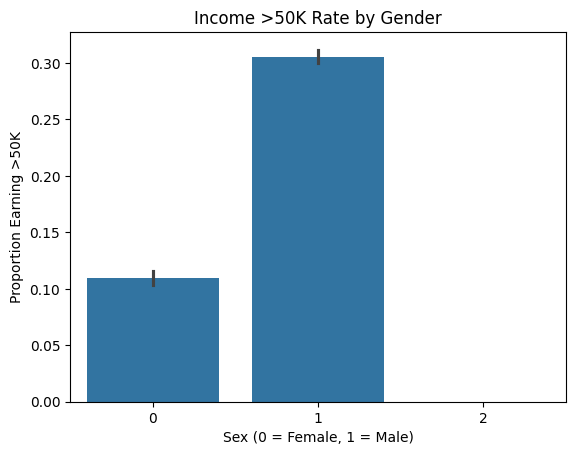

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='sex', y='income', data=df)
plt.title("Income >50K Rate by Gender")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Proportion Earning >50K")
plt.show()


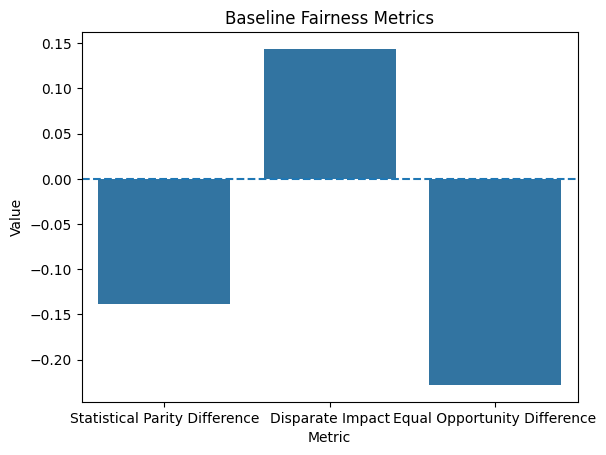

In [14]:
bias_metrics_df = pd.DataFrame({
    'Metric': [
        'Statistical Parity Difference',
        'Disparate Impact',
        'Equal Opportunity Difference'
    ],
    'Value': [
        baseline_fairness.statistical_parity_difference(),
        baseline_fairness.disparate_impact(),
        baseline_fairness.equal_opportunity_difference()
    ]
})

sns.barplot(x='Metric', y='Value', data=bias_metrics_df)
plt.title("Baseline Fairness Metrics")
plt.axhline(0, linestyle='--')
plt.show()


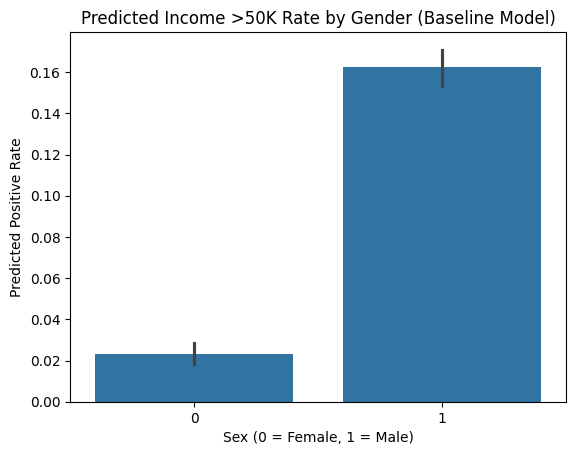

In [15]:
prediction_df = X_test.copy()
prediction_df['predicted_income'] = y_pred
prediction_df['sex'] = X_test['sex']

sns.barplot(x='sex', y='predicted_income', data=prediction_df)
plt.title("Predicted Income >50K Rate by Gender (Baseline Model)")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Predicted Positive Rate")
plt.show()


In [16]:
from aif360.algorithms.preprocessing import Reweighing

# Convert full dataset to AIF360 format
aif_data = BinaryLabelDataset(
    df=df,
    label_names=['income'],
    protected_attribute_names=['sex']
)

# Apply reweighing
rw = Reweighing(
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

rw_data = rw.fit_transform(aif_data)


In [17]:
df_rw, _ = rw_data.convert_to_dataframe()
df_rw.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,73.0,9.0,0.0,16.0,0.0,7.0,15.0,6.0,5.0,2.0,0.0,0.0,0.0,42.0,0.0
1,72.0,0.0,20408.0,11.0,16.0,6.0,0.0,1.0,4.0,0.0,1.0,87.0,35.0,39.0,0.0
2,65.0,4.0,2653.0,11.0,16.0,6.0,4.0,1.0,4.0,0.0,1.0,87.0,10.0,39.0,0.0
3,49.0,0.0,7319.0,15.0,2.0,6.0,0.0,4.0,2.0,0.0,1.0,87.0,35.0,39.0,0.0
4,37.0,4.0,3150.0,5.0,11.0,0.0,7.0,4.0,4.0,0.0,1.0,85.0,35.0,39.0,0.0


In [18]:
# Prepare features and target
X_rw = df_rw.drop('income', axis=1)
y_rw = df_rw['income']

# Train-test split
X_train_rw, X_test_rw, y_train_rw, y_test_rw = train_test_split(
    X_rw, y_rw, test_size=0.3, random_state=42, stratify=y_rw
)

# Scale features
scaler_rw = StandardScaler()
X_train_rw_scaled = scaler_rw.fit_transform(X_train_rw)
X_test_rw_scaled = scaler_rw.transform(X_test_rw)

# Train model
rw_model = LogisticRegression(max_iter=2000)
rw_model.fit(X_train_rw_scaled, y_train_rw)

# Predictions and accuracy
y_pred_rw = rw_model.predict(X_test_rw_scaled)
rw_accuracy = accuracy_score(y_test_rw, y_pred_rw)

rw_accuracy


0.7875934077182926

In [19]:
# Prepare test data for fairness evaluation
test_rw = X_test_rw.copy()
test_rw['income'] = y_test_rw.values

pred_rw = test_rw.copy()
pred_rw['income'] = y_pred_rw

aif_test_rw = BinaryLabelDataset(
    df=test_rw,
    label_names=['income'],
    protected_attribute_names=['sex']
)

aif_pred_rw = BinaryLabelDataset(
    df=pred_rw,
    label_names=['income'],
    protected_attribute_names=['sex']
)

rw_fairness = ClassificationMetric(
    aif_test_rw,
    aif_pred_rw,
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

print("REWEIGHING FAIRNESS METRICS")
print("SPD:", rw_fairness.statistical_parity_difference())
print("DI:", rw_fairness.disparate_impact())
print("EOD:", rw_fairness.equal_opportunity_difference())


REWEIGHING FAIRNESS METRICS
SPD: -0.13898136804569106
DI: 0.1437590646040302
EOD: -0.227952047952048


In [20]:
# Remove sensitive attribute from features
X_nosex = df.drop(['income', 'sex'], axis=1)
y_nosex = df['income']


In [21]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_nosex, y_nosex,
    test_size=0.3,
    random_state=42,
    stratify=y_nosex
)


In [22]:
scaler_ns = StandardScaler()

X_train_ns_scaled = scaler_ns.fit_transform(X_train_ns)
X_test_ns_scaled = scaler_ns.transform(X_test_ns)


In [23]:
model_ns = LogisticRegression(max_iter=2000)
model_ns.fit(X_train_ns_scaled, y_train_ns)

y_pred_ns = model_ns.predict(X_test_ns_scaled)
accuracy_ns = accuracy_score(y_test_ns, y_pred_ns)

accuracy_ns


0.7859555737537107

In [24]:
# Add sex back for fairness evaluation
test_ns = X_test_ns.copy()
test_ns['sex'] = X_test['sex'].values
test_ns['income'] = y_test_ns.values

pred_ns = test_ns.copy()
pred_ns['income'] = y_pred_ns

aif_test_ns = BinaryLabelDataset(
    df=test_ns,
    label_names=['income'],
    protected_attribute_names=['sex']
)

aif_pred_ns = BinaryLabelDataset(
    df=pred_ns,
    label_names=['income'],
    protected_attribute_names=['sex']
)

ns_fairness = ClassificationMetric(
    aif_test_ns,
    aif_pred_ns,
    unprivileged_groups=[{'sex': 0}],
    privileged_groups=[{'sex': 1}]
)

print("NO-SEX MODEL FAIRNESS METRICS")
print("SPD:", ns_fairness.statistical_parity_difference())
print("DI:", ns_fairness.disparate_impact())
print("EOD:", ns_fairness.equal_opportunity_difference())


NO-SEX MODEL FAIRNESS METRICS
SPD: -0.10689177119174048
DI: 0.27035721802870644
EOD: -0.17118881118881119


In [25]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Statistical Parity Difference",
        "Disparate Impact",
        "Equal Opportunity Difference"
    ],
    "Baseline Model": [
        baseline_accuracy,
        baseline_fairness.statistical_parity_difference(),
        baseline_fairness.disparate_impact(),
        baseline_fairness.equal_opportunity_difference()
    ],
    "After Reweighing": [
        rw_accuracy,
        rw_fairness.statistical_parity_difference(),
        rw_fairness.disparate_impact(),
        rw_fairness.equal_opportunity_difference()
    ],
    "No-Sex Model": [
        accuracy_ns,
        ns_fairness.statistical_parity_difference(),
        ns_fairness.disparate_impact(),
        ns_fairness.equal_opportunity_difference()
    ]
})

comparison_df


,Metric,Baseline Model,After Reweighing,No-Sex Model
0,Accuracy,0.787593,0.787593,0.785956
1,Statistical Parity Difference,-0.138981,-0.138981,-0.106892
2,Disparate Impact,0.143759,0.143759,0.270357
3,Equal Opportunity Difference,-0.227952,-0.227952,-0.171189


## Dataset Improvement Recommendations

1. **Increase representation of underrepresented groups**  
   The dataset shows significant disparities in income outcomes across gender groups. Collecting more representative data for women and marginalized racial groups would help reduce structural bias.

2. **Audit proxy variables**  
   Features such as occupation, education level, and hours worked may encode historical gender inequality and act as indirect proxies for protected attributes. These variables should be reviewed and potentially transformed or grouped more carefully.

3. **Include contextual and socio-economic factors**  
   The dataset lacks contextual variables such as caregiving responsibilities or employment interruptions, which disproportionately affect women and may distort income predictions.

4. **Conduct continuous bias monitoring**  
   Fairness metrics should be recalculated regularly as societal conditions and data distributions evolve to prevent the reintroduction of bias over time.


## Real-World Implications and Potential Harms

Bias in income prediction models can lead to serious real-world consequences when deployed in high-stakes decision-making systems. Models trained on biased data may unfairly disadvantage certain demographic groups, particularly women and racial minorities.

In employment contexts, biased income or salary prediction models may influence hiring, promotion, or compensation decisions, reinforcing existing workplace inequalities. In financial services, such models could affect loan approvals or credit scoring, limiting access to financial opportunities for already marginalized groups.

The results of this bias audit demonstrate that even when explicit sensitive attributes such as sex are removed, disparities persist due to proxy variables. This highlights the risk of indirect discrimination, where protected characteristics are inferred through correlated features.

If left unaddressed, these systems may automate and legitimize discrimination at scale, making bias less visible and harder to challenge. Therefore, fairness auditing and mitigation are essential before deploying machine learning models in real-world socio-economic applications.


## Ethics Framework for Income Prediction Systems

This bias audit is guided by core ethical principles commonly applied to responsible artificial intelligence: fairness, non-maleficence, accountability, and transparency.

**Fairness** requires that income prediction models do not systematically disadvantage specific demographic groups. The findings of this audit demonstrate that gender-based disparities exist in both the dataset and model predictions, indicating a violation of this principle when left unmitigated.

**Non-maleficence** emphasizes the obligation to avoid harm. In income-related decision-making, biased predictions can restrict access to employment opportunities, financial services, and economic mobility. Mitigation strategies are therefore necessary to prevent the amplification of social inequalities.

**Accountability** demands that model developers and organizations take responsibility for identifying, documenting, and addressing bias. This audit illustrates the importance of evaluating multiple fairness metrics and acknowledging when mitigation strategies have limited effectiveness.

**Transparency** involves making model behavior and limitations understandable to stakeholders. By clearly reporting fairness metrics, visualizations, and trade-offs between accuracy and equity, this analysis promotes informed decision-making and ethical deployment.

Together, these principles form an ethics framework that supports the responsible use of machine learning systems in income prediction and related socio-economic applications.


## References

Bellamy, R. K. E., Dey, K., Hind, M., Hoffman, S. C., Houde, S., Kannan, K., 
Liao, Q. V., Martino, J., Mehta, S., Mojsilović, A., Nagar, S., Ramamurthy, K. N., 
Richards, J., Saha, D., Sattigeri, P., Singh, M., Varshney, K. R., & Zhang, Y. (2018). 
*AI Fairness 360: An extensible toolkit for detecting, understanding, and mitigating unwanted algorithmic bias.*

Hardt, M., Price, E., & Srebro, N. (2016). 
*Equality of opportunity in supervised learning.*

Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2019). 
*A survey on bias and fairness in machine learning.*

Barocas, S., Hardt, M., & Narayanan, A. (2019). 
*Fairness and machine learning.*

European Commission. (2019). 
*Ethics guidelines for trustworthy artificial intelligence.*
